In [19]:
import dpluspy
import demes 
import moments
import msprime
import numpy as np

In [20]:
"""
The underlying model (model0) is an equilibrium population. We will perform the 
LRT with model0 as the null hypothesis, challenging it with a spurious model of 
recent expansion (model1).
"""

# Define paths to models
model0_file = "graph0.yaml"
params0_file = "params0.yaml"
model1_file = "graph1.yaml"
params1_file = "params1.yaml"

# Set up models, parameters and write them to disk.
model0_str = """time_units: generations
demes:
- name: popX
  epochs:
  - {end_time: 0, start_size: 15000}
"""

params0_str = """parameters: 
- name: N_0
  lower_bound: 1
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            0: start_size
"""

model1_str = """time_units: generations
demes:
- name: popX
  epochs:
  - {end_time: 3000, start_size: 15000}
  - {end_time: 0, start_size: 30000}
"""

params1_str = """parameters: 
- name: N_0
  lower_bound: 1
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            0: start_size
- name: T_EXP
  lower_bound: 1e-10
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            0: end_time
- name: N_1
  lower_bound: 1
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            1: start_size
"""

with open(model0_file, "w") as fout:
    fout.write(model0_str)
with open(params0_file, "w") as fout:
    fout.write(params0_str)

with open(model1_file, "w") as fout:
    fout.write(model1_str)
with open(params1_file, "w") as fout:
    fout.write(params1_str)

In [21]:
# Parameters
r = 1e-8
u = 1.3e-8
u_std = 1e-9
L = int(5e6)
n_reps = 100
pop_ids = ["popX"]
samples = {pop_id: 1 for pop_id in pop_ids}
bins = np.logspace(-6, -2, 17)

In [22]:
# Define simulation and D+ parsing functions
def simulate():
    graph = demes.load(model0_file)
    demog = msprime.Demography.from_demes(graph)
    tss = msprime.sim_ancestry(
        demography=demog,
        samples=samples,
        sequence_length=L,
        recombination_rate=r,
        num_replicates=n_reps,
    )
    mtss = [msprime.sim_mutations(ts, rate=np.random.normal(u, u_std)) 
        for ts in tss]
    return mtss


def parse_stats(mtss):
    # Parse statistics from simulation results
    intervals = [[1, L + 1, L + 1]]
    pop_mapping = {x: [x] for x in samples} 
    stats = dict()
    for ii, ts in enumerate(mtss):
        if ii == 0:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=True,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
        else:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=False,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
            for jj in range(len(intervals)):
                stats_ii[(ii, jj)]["denoms"] = stats[(0, jj)]["denoms"]
        stats.update(stats_ii)
    return stats

In [23]:
# Run simulations
mtss = simulate()

In [24]:
# Parse statistics and do the bootstrap
stats = parse_stats(mtss)
bootreps = dpluspy.bootstrapping.get_bootstrap_reps(
    stats, num_reps=100, weighted=False)
varcovs = dpluspy.bootstrapping.compute_varcovs(bootreps)
means = dpluspy.bootstrapping.means_across_regions(stats)

In [25]:
def fit_model(graph_file, param_file, output):
    """
    Fit a model in two stages; return fitted parameters and ll.
    """
    dpluspy.inference.optimize(
        graph_file,
        param_file,
        means,
        varcovs,
        pop_ids=pop_ids,
        bins=bins,
        u=u,
        perturb=0.2,
        method="lbfgsb",
        log=True,
        max_iter=10000,
        verbose=False,
        output="intermediate.yaml",
        overwrite=True
    )
    ret = dpluspy.inference.optimize(
        "intermediate.yaml",
        param_file,
        means,
        varcovs,
        pop_ids=pop_ids,
        bins=bins,
        u=u,
        method="powell",
        log=True,
        max_iter=100,
        verbose=False,
        output=output,
        overwrite=True
    )
    return ret

In [26]:
# Fit the underlying and complex models; try to force ll1 > ll0
out0 = "fit0.yaml"
out1 = "fit1.yaml"
pnames0, params0, ll0 = fit_model(model0_file, params0_file, out0)
ll1 = -1e10
max_tries = 20
tries = 0
while ll1 <= ll0:
    pnames1, params1, ll1 = fit_model(model1_file, params1_file, out1)
    tries += 1
    if tries > max_tries:
        raise ValueError("Cannot achieve ll1 > ll0")

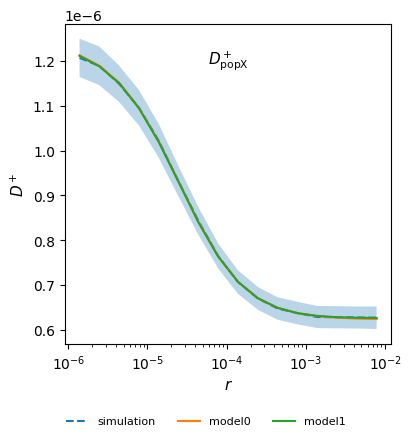

In [27]:
# Plot model fits
model0 = dpluspy.inference.compute_bin_stats(out0, bins=bins, u=u, 
    sampled_demes=pop_ids)
model1 = dpluspy.inference.compute_bin_stats(out1, bins=bins, u=u, 
    sampled_demes=pop_ids)
dpluspy.plotting.plot_d_plus_curves(models=[model0, model1], bins=bins, 
    pop_ids=pop_ids, means=means, varcovs=varcovs, ax_size=4,
    labels=["simulation", "model0", "model1"])

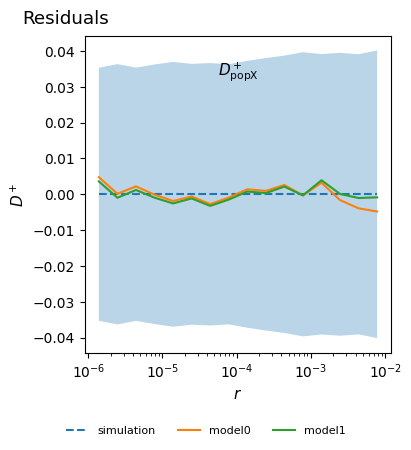

In [28]:
# Plot errors against simulated data
res0 = [(m - s) / s for m, s in zip(model0, means)]
res1 = [(m - s) / s for m, s in zip(model1, means)]
zeros = [np.array([0])] * len(means)
vs = [v / s ** 2 for v, s in zip(varcovs, means)]
dpluspy.plotting.plot_d_plus_curves(models=[res0, res1], bins=bins, 
    varcovs=vs, means=zeros, pop_ids=pop_ids, ax_size=4,
    labels=["simulation", "model0", "model1"],
    title="Residuals")

In [29]:
# Summarize fitted parameters
print(f"Model 0 (null, true) ll = {ll0:.3}")
print("Param\tvalue")
for name, val in zip(pnames0, params0):
    print(f"{name}\t{val:.3}")

print(f"\nModel 1 (full, spurious) ll = {ll1:.3}")
print("Param\tvalue")
for name, val in zip(pnames1, params1):
    print(f"{name}\t{val:.3}")

# We have two nested parameters; one at a boundary (T_EXP) and one not (N_1)
weights = (0, 0.5, 0.5)
D_naive = 2 * (ll1 - ll0)
p_naive = moments.Godambe.sum_chi2_ppf(D_naive, weights=weights)

print("\nNaive (unadjusted) LR statistic:")
print(f"D =\t{D_naive:.3}")
print(f"p =\t{p_naive:.3}")

Model 0 (null, true) ll = -0.136
Param	value
N_0	1.52e+04

Model 1 (full, spurious) ll = -0.0827
Param	value
N_0	1.51e+04
T_EXP	2.53e+02
N_1	1e+05

Naive (unadjusted) LR statistic:
D =	0.106
p =	0.846


In [30]:
# Compute model uncertainties
def get_uncerts(graph_file, param_file):
    ret = dpluspy.uncerts.GIM_uncerts(
        graph_file, 
        param_file,
        means,
        varcovs,
        pop_ids=pop_ids,
        bins=bins,
        u=u,
        bootstrap_reps=bootreps,
        delta=0.01,
        verbose=False
    )
    return ret

_, __, uncerts0 = get_uncerts(out0, params0_file)
_, __, uncerts1 = get_uncerts(out1, params1_file)

print(f"Model 0")
print("Param\t2.5% CI\t97.5% CI")
for name, val, std in zip(pnames0, params0, uncerts0):
    print(f"{name}\t{val - 1.96 * std:.3}\t{val + 1.96 * std:.3}")

print(f"\nModel 1")
print("Param\t2.5% CI\t97.5% CI")
for name, val, std in zip(pnames1, params1, uncerts1):
    print(f"{name}\t{val - 1.96 * std:.3}\t{val + 1.96 * std:.3}")

Model 0
Param	2.5% CI	97.5% CI
N_0	1.49e+04	1.55e+04

Model 1
Param	2.5% CI	97.5% CI
N_0	1.48e+04	1.54e+04
T_EXP	-1.29e+02	6.36e+02
N_1	-1.73e+04	2.17e+05


In [31]:
# Compute the LRT adjustment.

# Set up complex model arguments
_, __, model_args = dpluspy.uncerts.set_up_model_args(
    model1_file, params1_file, bins=bins, pop_ids=pop_ids, u=u)

# We want to evaluate the adjustment with the complex model at the simple model 
# MLE parameters. To accomplish this we should nominally use [N_0, T_EXP, N_1] 
# = [N_0, 0, N_0], but setting the time parameter to 0 creates an invalid epoch.
# So we set it to a value that is close to 0.
N_0 = params0[0]
p_lrt = np.array([N_0, 0.01, N_0])

# This step size is formulated as 2 * N_0 * delta, which is probably what the
# default behavior in dadi/moments would be since these scale time by 2 * N_A
step_T_EXP = 2 * N_0 * 0.01
# This seems the most reasonable step size for N_1.
step_N_1 = N_0 * 0.01
steps = np.array([step_T_EXP, step_N_1])
nested_idx = np.array([1, 2])

# Print a summary of the parameter setup
print("Param\tvalue\tnested?\tstep")
nest_idx = 0
for ii, (name, val) in enumerate(zip(pnames1, p_lrt)):
    nested = True if ii in nested_idx else False
    if nested:
        step = f"{steps[nest_idx]:.3}"
        nest_idx += 1
    else:
        step = "---"
    print(f"{name}\t{val:.3}\t{nested}\t{step}")

adj, GIM, HH, JJ = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0,
    return_GIM=True
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj =\t{adj:.3}")
print(f"D_adj =\t{D_adj:.3}")
print(f"p =\t{p_adj:.3}")

Param	value	nested?	step
N_0	1.52e+04	False	---
T_EXP	0.01	True	3.04e+02
N_1	1.52e+04	True	1.52e+02

adj =	-3.84e+14
D_adj =	-4.09e+13
p =	1.0


In [32]:
print("GIM")
print(GIM)
# Why is the variance of T_EXP so small?
print("\nGIM^-1")
print(np.linalg.inv(GIM))

GIM
[[ 3.01308285e+02 -1.18202322e+09]
 [-1.18202322e+09  4.68360281e+15]]

GIM^-1
[[3.33840939e-01 8.42530328e-08]
 [8.42530328e-08 2.14768512e-14]]


In [33]:
# What happens if we evaluate the adjustment at the complex model MLE params?
p_lrt = params1
steps = p_lrt[1:] * 0.01

adj, GIM, HH, JJ = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0,
    return_GIM=True
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj =\t{adj:.3}")
print(f"D_adj =\t{D_adj:.3}")
print(f"p =\t{p_adj:.3}")


adj =	0.136
D_adj =	0.0144
p =	0.949
